In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
dataset_path = "/Users/swechhyapradhan/Desktop/Pneumonia CNN/dataset"

In [3]:
train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')
test_dir = os.path.join(dataset_path, 'test')

In [4]:
img_height, img_width = 224, 224
batch_size = 32
epochs = 25

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)  # No augmentation for val/test

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 20450 images belonging to 3 classes.
Found 2534 images belonging to 3 classes.
Found 2569 images belonging to 3 classes.


In [6]:
class_indices = train_generator.class_indices
print("✅ Class mapping:", class_indices)
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

✅ Class mapping: {'normal': 0, 'pneumonia': 1, 'tuberculosis': 2}


In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes: Normal, Pneumonia, Tuberculosis
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/swechhyapradhan/Desktop/Pneumonia CNN/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,680,067 (36.93 MB)

 Trainable params: 9,680,067 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 900s 1s/step - accuracy: 0.6563 - loss: 0.6637 - val_accuracy: 0.7088 - val_loss: 0.5855
Epoch 2/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 829s 1s/step - accuracy: 0.7089 - loss: 0.5549 - val_accuracy: 0.7285 - val_loss: 0.5322
Epoch 3/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 822s 1s/step - accuracy: 0.7221 - loss: 0.5114 - val_accuracy: 0.7305 - val_loss: 0.5028
Epoch 4/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.7322 - loss: 0.4920 - val_accuracy: 0.7439 - val_loss: 0.4636
Epoch 5/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 501s 782ms/step - accuracy: 0.7352 - loss: 0.4716 - val_accuracy: 0.7313 - val_loss: 0.4741
Epoch 6/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 506s 790ms/step - accuracy: 0.7428 - loss: 0.4628 - val_accuracy: 0.7490 - val_loss: 0.4763
Epoch 7/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 534s 834ms/step - accuracy: 0.7419 - loss: 0.4547 - val_accuracy: 0.7403 - val_loss: 0.4599
Epoch 8/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 541s 845ms/step - accuracy: 0.7456 - loss: 0.446

In [10]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 384ms/step - accuracy: 0.7649 - loss: 0.4449

✅ Test Accuracy: 0.7649
✅ Test Loss: 0.4449


In [11]:
model.save("pneumonia_cnn_model.h5")
print("\n✅ Model saved as 'pneumonia_cnn_model.h5'")


✅ Model saved as 'pneumonia_cnn_model.h5'


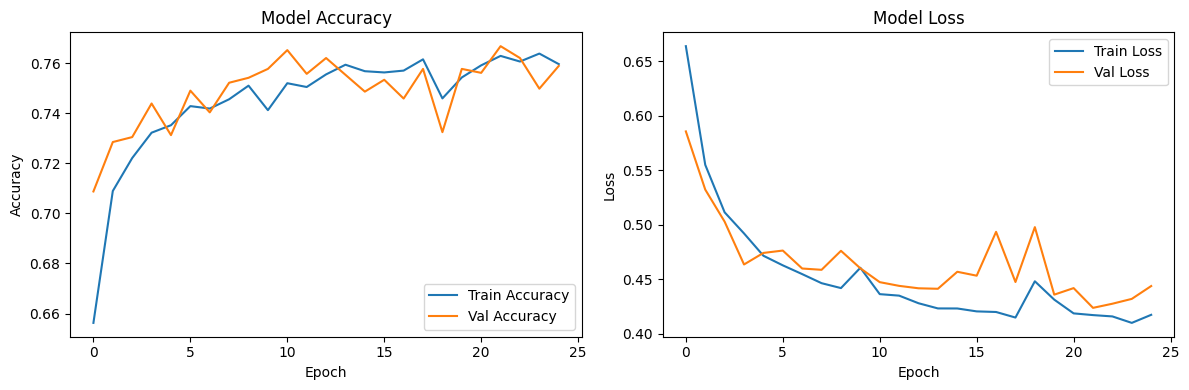

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()